# Imports

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor
import joblib


# Dataset for training and testing

In [31]:
df = pd.read_csv("movements.csv")

X = df[["direction", "steps", "step_size", "battery_volt"]]
y = df[["distance_x", "distance_y"]]

print(f"Dataset: {len(df)} samples")
print(f"Directions: {sorted(df['direction'].unique())}")
print(f"Steps range: {df['steps'].min()}-{df['steps'].max()}")
print(f"Battery: {df['battery_volt'].min():.2f}-{df['battery_volt'].max():.2f} V\n")

Dataset: 600 samples
Directions: ['b', 'f', 'l', 'r']
Steps range: 1-10
Battery: 6.39-7.96 V



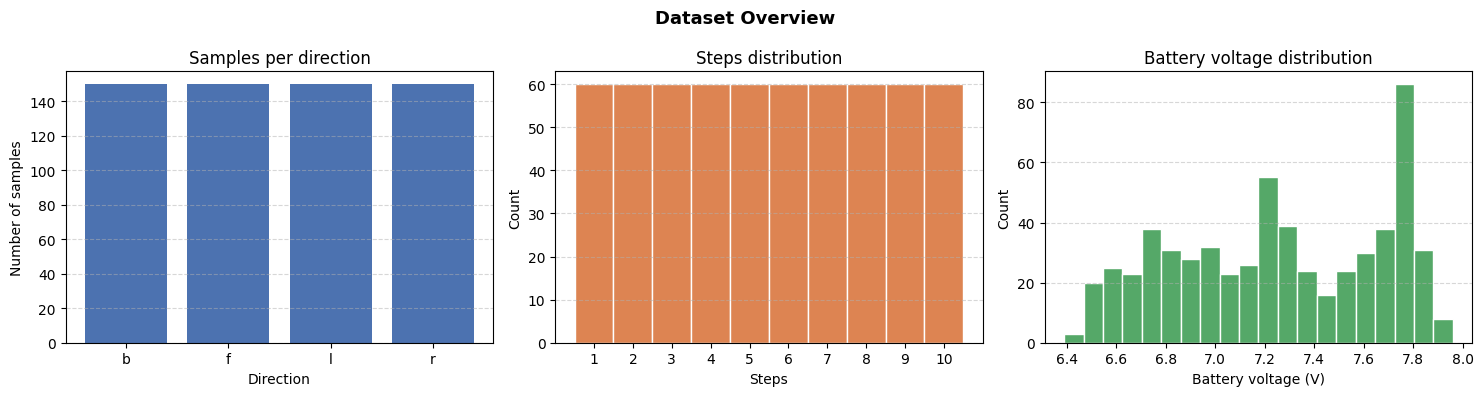

In [35]:
# Graphic visualizations of the dataset to observe the distribution of the different metrics

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Dataset Overview", fontsize=13, fontweight="bold")

counts = df["direction"].value_counts().sort_index()
axes[0].bar(counts.index, counts.values, color="#4C72B0")
axes[0].set_xlabel("Direction")
axes[0].set_ylabel("Number of samples")
axes[0].set_title("Samples per direction")
axes[0].grid(axis="y", linestyle="--", alpha=0.5)

axes[1].hist(df["steps"], bins=range(1, 12), color="#DD8452", edgecolor="white", align="left")
axes[1].set_xlabel("Steps")
axes[1].set_ylabel("Count")
axes[1].set_title("Steps distribution")
axes[1].set_xticks(range(1, 11))
axes[1].grid(axis="y", linestyle="--", alpha=0.5)

axes[2].hist(df["battery_volt"], bins=20, color="#55A868", edgecolor="white")
axes[2].set_xlabel("Battery voltage (V)")
axes[2].set_ylabel("Count")
axes[2].set_title("Battery voltage distribution")
axes[2].grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


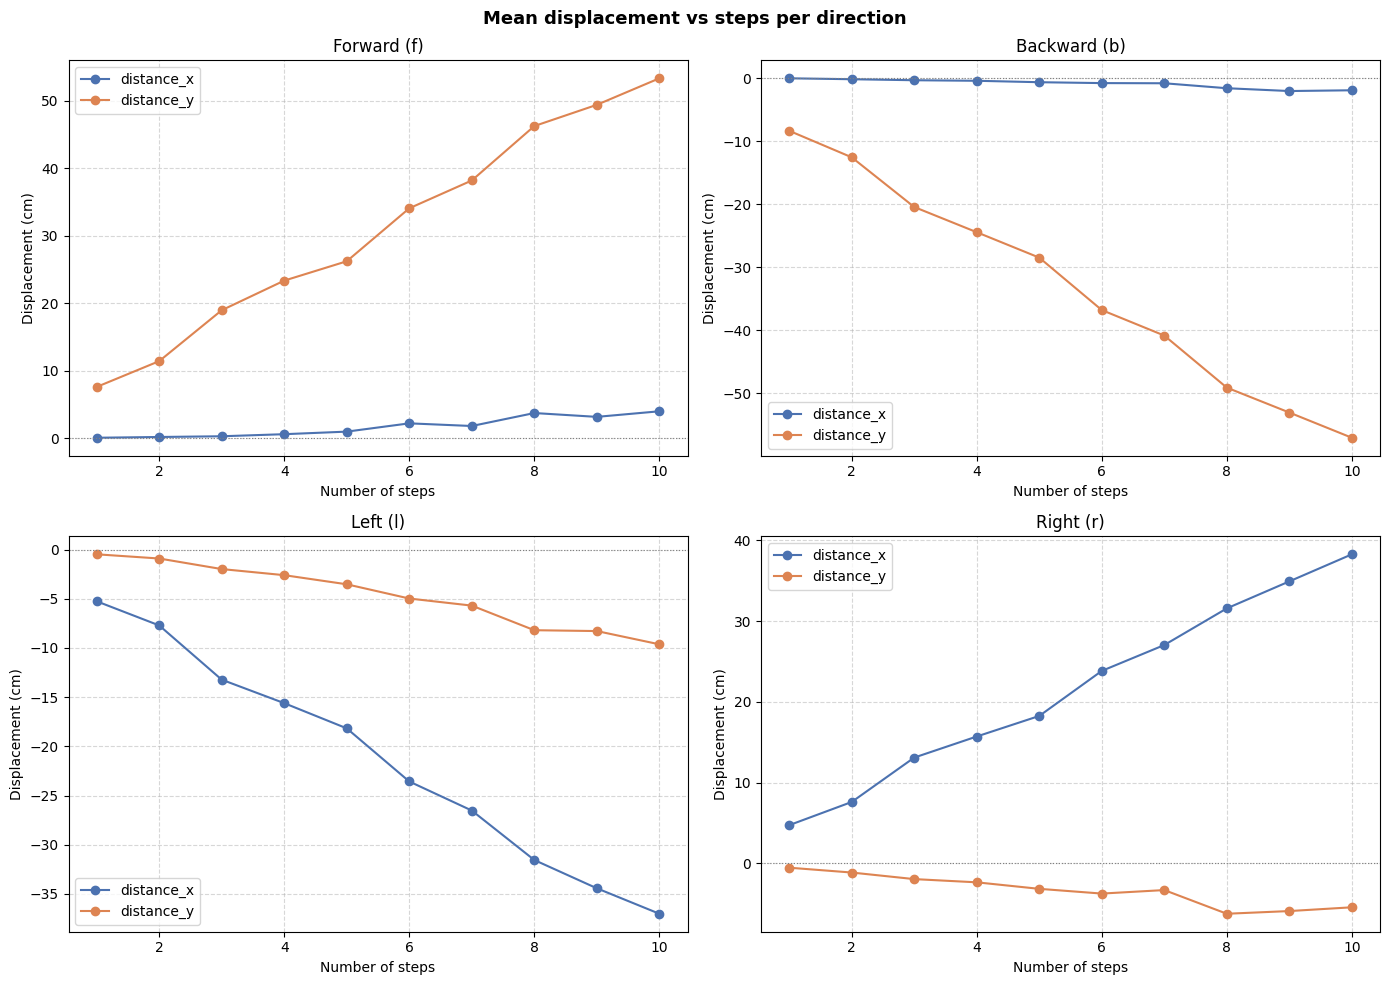

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Mean displacement vs steps per direction", fontsize=13, fontweight="bold")

dir_labels = {"f": "Forward", "b": "Backward", "l": "Left", "r": "Right"}
axis_colors = {"distance_x": "#4C72B0", "distance_y": "#DD8452"}

for ax, direction in zip(axes.flatten(), ["f", "b", "l", "r"]):
    sub = df[df["direction"] == direction]
    grouped = sub.groupby("steps")[["distance_x", "distance_y"]]
    means = grouped.mean()
    steps = means.index

    for col, color in axis_colors.items():
        ax.plot(steps, means[col], marker="o", color=color, label=col)

    ax.axhline(0, color="gray", lw=0.8, linestyle=":")
    ax.set_title(dir_labels[direction] + " (" + direction + ")")
    ax.set_xlabel("Number of steps")
    ax.set_ylabel("Displacement (cm)")
    ax.legend()
    ax.grid(linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


# Model Definition

In [62]:
# Using 'OneHotEncoder' to encode directions into numeric values
#Using 'StandardScaler' to avoid the models to consider some values most important than others
preprocessor = ColumnTransformer(transformers=[
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), ["direction"]),
    ("num", StandardScaler(), ["steps", "step_size", "battery_volt"]),
])

def build_pipeline(model):
    return Pipeline([("preprocess", preprocessor), ("model", model)])

models = {
    "Random Forest": build_pipeline(
        RandomForestRegressor(
            n_estimators=200, min_samples_leaf=2, random_state=42, n_jobs=-1
        )
    ),
    "XGBoost": build_pipeline(
        MultiOutputRegressor(
            XGBRegressor(
                n_estimators=200, learning_rate=0.05,
                max_depth=6, random_state=42, verbosity=0
            )
        )
    ),
    "MLP": build_pipeline(
        MLPRegressor(
            hidden_layer_sizes=(128, 64, 32), activation="relu",
            max_iter=1000, early_stopping=True, random_state=42
        )
    ),
}


# Training

In [39]:
# 5-fold cross-validation to use 480 data for training and 120 for testing
kf = KFold(n_splits=5, shuffle=True, random_state=42)

results = []  # Global metrics per model
cv_dir_results = []  # Single directions metrics per model
oof_preds = {}  # Out-of-Fold predictions, reused in all plots

for name, pipeline in models.items():
    mae_x, mae_y, rmse_x, rmse_y, r2_x, r2_y = [], [], [], [], [], []

    for train_idx, test_idx in kf.split(X):
        X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
        y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]
        pipeline.fit(X_tr, y_tr)
        pred = pipeline.predict(X_te)

        mae_x.append(mean_absolute_error(y_te["distance_x"],  pred[:, 0]))
        mae_y.append(mean_absolute_error(y_te["distance_y"],  pred[:, 1]))
        rmse_x.append(np.sqrt(mean_squared_error(y_te["distance_x"], pred[:, 0])))
        rmse_y.append(np.sqrt(mean_squared_error(y_te["distance_y"], pred[:, 1])))
        r2_x.append(r2_score(y_te["distance_x"], pred[:, 0]))
        r2_y.append(r2_score(y_te["distance_y"], pred[:, 1]))

    results.append({
        "Model":        name,
        "MAE x (cm)": round(np.mean(mae_x), 4),
        "MAE y (cm)": round(np.mean(mae_y), 4),
        "RMSE x (cm)": round(np.mean(rmse_x), 4),
        "RMSE y (cm)": round(np.mean(rmse_y), 4),
        "R² x": round(np.mean(r2_x), 4),
        "R² y": round(np.mean(r2_y), 4),
        "Mean R²": round((np.mean(r2_x) + np.mean(r2_y)) / 2, 4),
    })

    # OOF predictions via cross_val_predict that is equivalent to the loop above, 
    #  but it returns one prediction per sample each from a fold that excluded it
    oof_preds[name] = cross_val_predict(pipeline, X, y, cv=kf)

    # Per-direction metrics computed on OOF predictions
    for direction in ["f", "b", "l", "r"]:
        mask = X["direction"] == direction
        oof = oof_preds[name]
        r2x = r2_score(y.loc[mask, "distance_x"], oof[mask, 0])
        r2y = r2_score(y.loc[mask, "distance_y"], oof[mask, 1])
        cv_dir_results.append({
            "Model": name,
            "Direction": direction,
            "MAE x (cm)": round(mean_absolute_error(y.loc[mask, "distance_x"], oof[mask, 0]), 4),
            "MAE y (cm)": round(mean_absolute_error(y.loc[mask, "distance_y"], oof[mask, 1]), 4),
            "RMSE x (cm)": round(np.sqrt(mean_squared_error(y.loc[mask, "distance_x"], oof[mask, 0])), 4),
            "RMSE y (cm)": round(np.sqrt(mean_squared_error(y.loc[mask, "distance_y"], oof[mask, 1])), 4),
            "R² x": round(r2x, 4),
            "R² y": round(r2y, 4),
            "Mean R²": round((r2x + r2y) / 2, 4),
        })
    print(f"- {name} done")


- Random Forest done
- XGBoost done
- MLP done


In [40]:
df_results = (pd.DataFrame(results).sort_values("Mean R²", ascending=False).reset_index(drop=True))
df_cv_dir = (pd.DataFrame(cv_dir_results).sort_values(["Model", "Direction"]).reset_index(drop=True))

print("Global CV metrics directions:\n")
display(df_results)
print("\nSingle directions CV metrics:\n")
display(df_cv_dir)


Global CV metrics directions:



,Model,MAE x (cm),MAE y (cm),RMSE x (cm),RMSE y (cm),R² x,R² y,Mean R²
0,Random Forest,1.0238,0.9860,1.4724,1.3890,0.9924,0.9969,0.9947
1,XGBoost,1.0806,1.0323,1.5314,1.4880,0.9918,0.9965,0.9941
2,MLP,1.1412,1.3120,1.5570,1.7192,0.9915,0.9953,0.9934



Single directions CV metrics:



,Model,Direction,MAE x (cm),MAE y (cm),RMSE x (cm),RMSE y (cm),R² x,R² y,Mean R²
0,MLP,b,0.8014,1.4319,1.2145,1.7099,0.0790,0.9888,0.5339
1,MLP,f,1.2448,1.4331,1.7479,1.7248,0.3472,0.9870,0.6671
2,MLP,l,1.2250,0.9139,1.4911,1.2715,0.9801,0.8524,0.9163
3,MLP,r,1.2936,1.4691,1.7202,2.0862,0.9755,0.4128,0.6941
4,Random Forest,b,0.6911,0.8179,1.0912,1.1072,0.2565,0.9953,0.6259
5,Random Forest,f,1.2947,0.8744,1.8833,1.1088,0.2422,0.9946,0.6184
6,Random Forest,l,0.9926,0.8839,1.3672,1.2849,0.9833,0.8493,0.9163
7,Random Forest,r,1.1169,1.3680,1.4486,1.9098,0.9826,0.5079,0.7452
8,XGBoost,b,0.7897,0.8494,1.2193,1.1667,0.0718,0.9948,0.5333
9,XGBoost,f,1.2955,0.9275,1.8117,1.1619,0.2987,0.9941,0.6464


# Model Analysis
(using Out-of-Fold predictions)

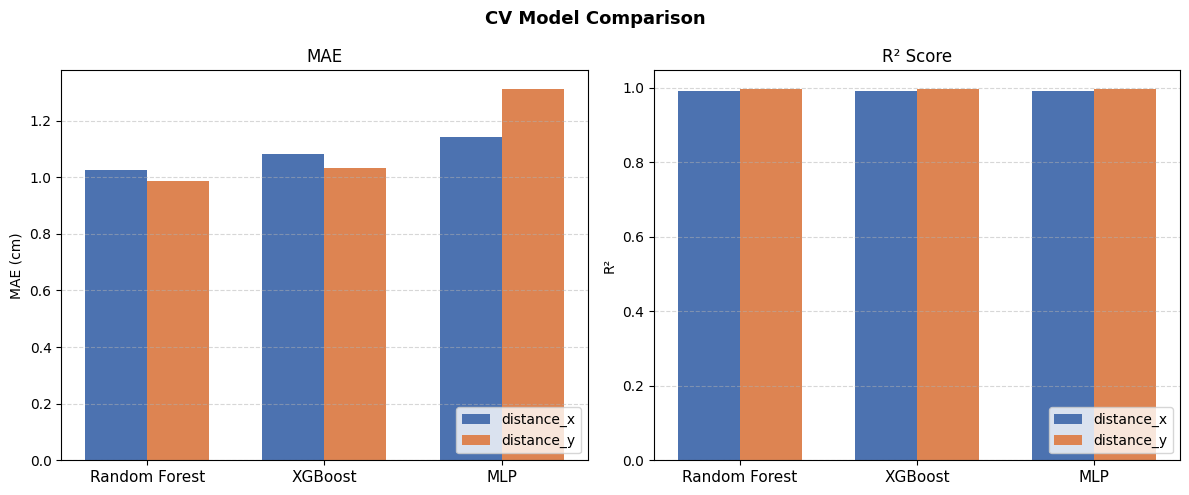

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("CV Model Comparison", fontsize=13, fontweight="bold")

names = df_results["Model"]
x = np.arange(len(names))
w = 0.35

axes[0].bar(x - w/2, df_results["MAE x (cm)"], w, label="distance_x", color="#4C72B0")
axes[0].bar(x + w/2, df_results["MAE y (cm)"], w, label="distance_y", color="#DD8452")
axes[0].set_xticks(x)
axes[0].set_xticklabels(names, fontsize=11)
axes[0].set_ylabel("MAE (cm)")
axes[0].set_title("MAE")
axes[0].legend(loc="lower right")
axes[0].grid(axis="y", linestyle="--", alpha=0.5)

axes[1].bar(x - w/2, df_results["R² x"], w, label="distance_x", color="#4C72B0")
axes[1].bar(x + w/2, df_results["R² y"], w, label="distance_y", color="#DD8452")
axes[1].set_xticks(x)
axes[1].set_xticklabels(names, fontsize=11)
axes[1].set_ylabel("R²")
axes[1].set_title("R² Score")
axes[1].legend(loc="lower right")
axes[1].grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


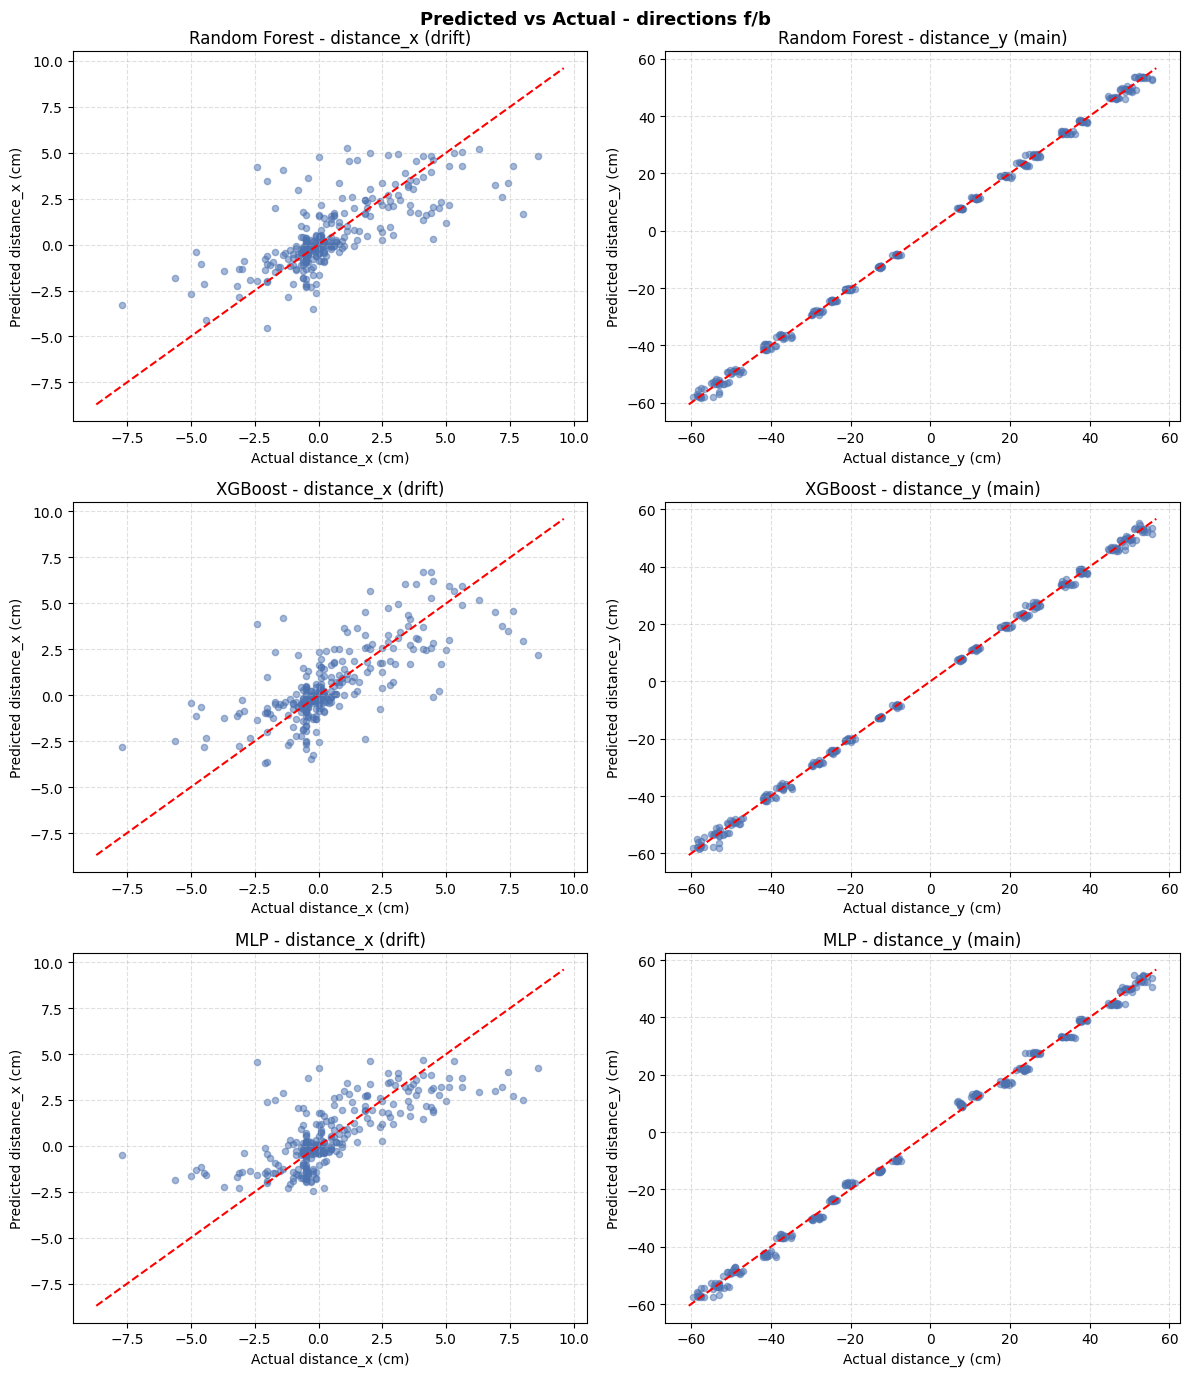

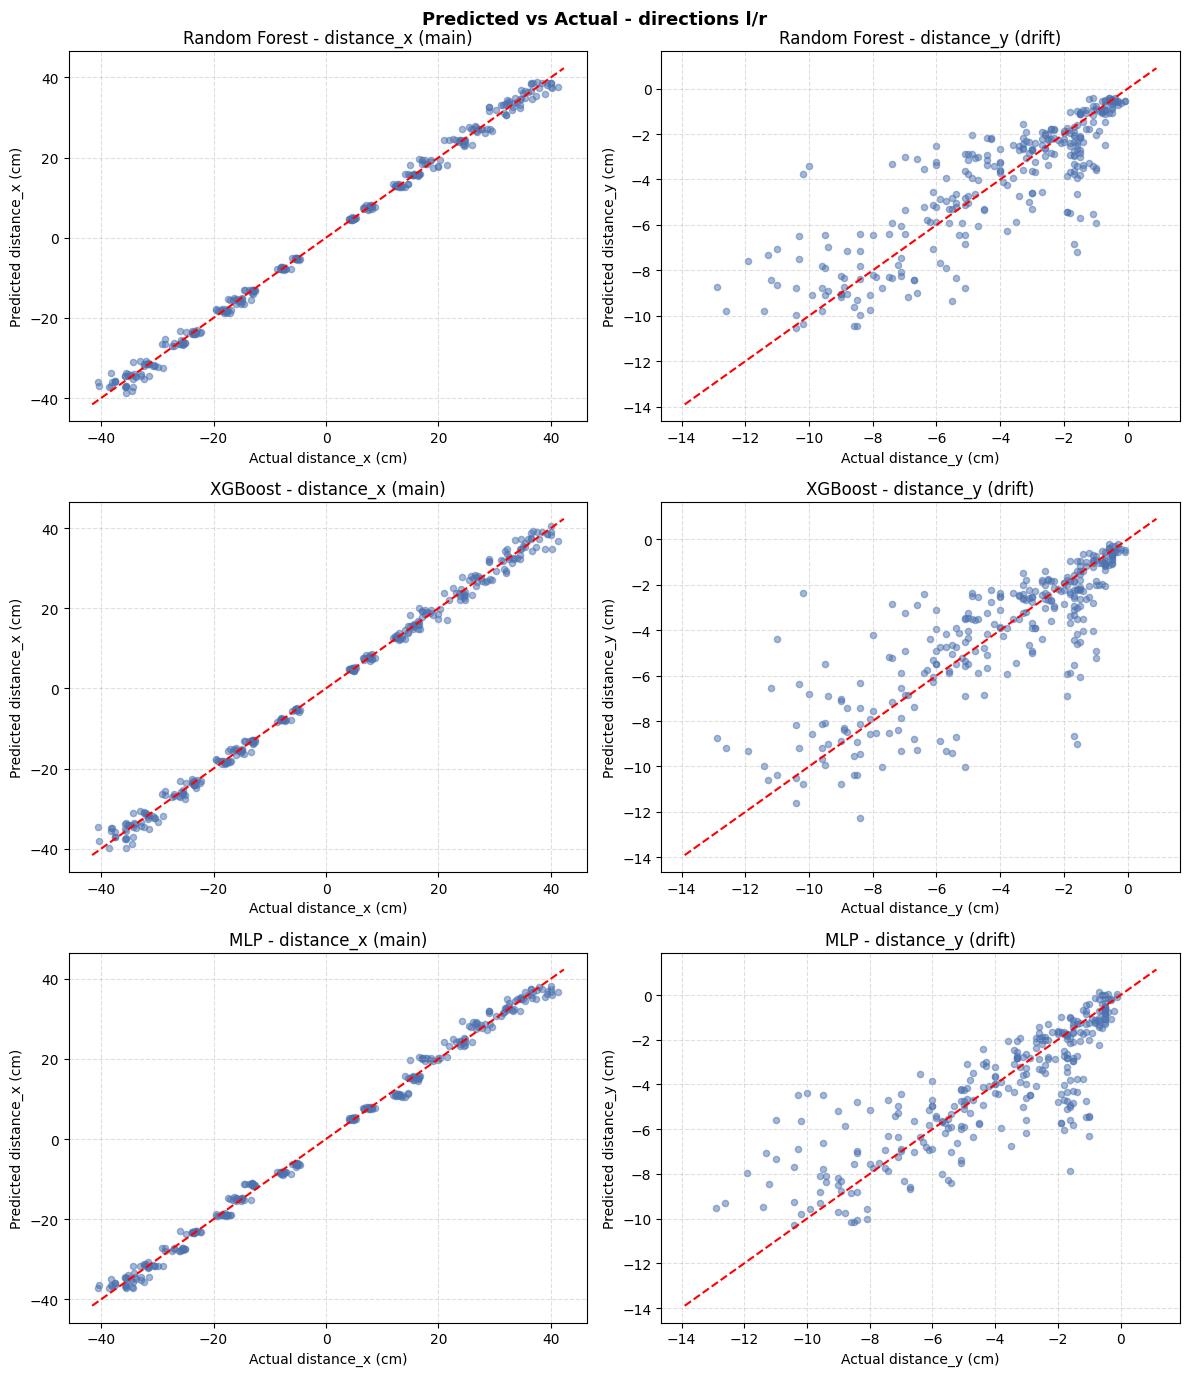

In [9]:
# For each group of directions sharing the same main axis, are shown both the main axis prediction and the drift

for group_dirs, group_label in [(["f", "b"], "f/b"), (["l", "r"], "l/r")]:
    fig, axes = plt.subplots(3, 2, figsize=(12, 14))
    fig.suptitle("Predicted vs Actual - directions " + group_label, fontsize=13, fontweight="bold")
    mask = X["direction"].isin(group_dirs).values

    for row_idx, name in enumerate(models):
        oof = oof_preds[name]
        for col_idx, col_name in enumerate(["distance_x", "distance_y"]):
            ax = axes[row_idx][col_idx]
            actual = y.loc[mask, col_name].values
            predicted = oof[mask, col_idx]
            lim_min = min(actual.min(), predicted.min()) - 1
            lim_max = max(actual.max(), predicted.max()) + 1

            is_main = (
                (group_dirs == ["f", "b"] and col_name == "distance_y") or
                (group_dirs == ["l", "r"] and col_name == "distance_x")
            )
            axis_note = "main" if is_main else "drift"

            ax.scatter(actual, predicted, alpha=0.5, s=20, color="#4C72B0")
            ax.plot([lim_min, lim_max], [lim_min, lim_max], "r--", lw=1.5)
            ax.set_xlabel("Actual " + col_name + " (cm)")
            ax.set_ylabel("Predicted " + col_name + " (cm)")
            ax.set_title(name + " - " + col_name + " (" + axis_note + ")")
            ax.grid(linestyle="--", alpha=0.4)

    plt.tight_layout()
    plt.show()


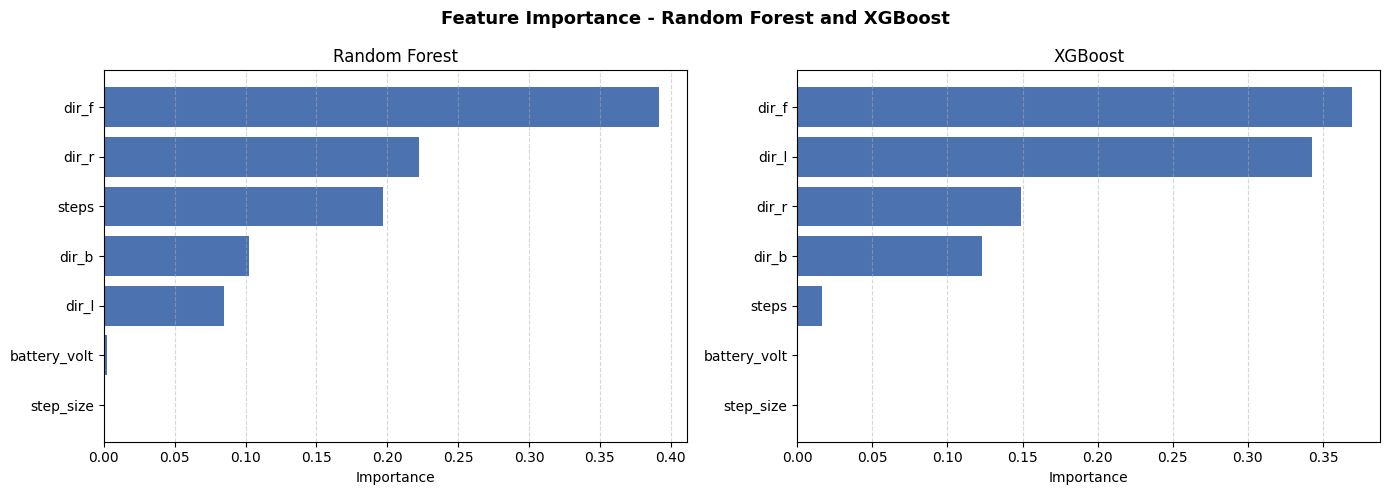

In [41]:
# Comparison of feature_importance to see the importance of the battery_volt parameter

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Feature Importance - Random Forest and XGBoost",
             fontsize=13, fontweight="bold")

for ax, name in zip(axes, ["Random Forest", "XGBoost"]):
    pipeline = models[name]
    model = pipeline.named_steps["model"]

    if isinstance(model, MultiOutputRegressor):
        importances = np.mean([est.feature_importances_ for est in model.estimators_], axis=0)
    else:
        importances = model.feature_importances_

    ohe_cats = pipeline.named_steps["preprocess"].transformers_[0][1].categories_[0]
    ohe_names = ["dir_" + c for c in ohe_cats]
    feat_names = ohe_names + ["steps", "step_size", "battery_volt"]

    idx = np.argsort(importances)
    ax.barh([feat_names[i] for i in idx], importances[idx], color="#4C72B0")
    ax.set_xlabel("Importance")
    ax.set_title(name)
    ax.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


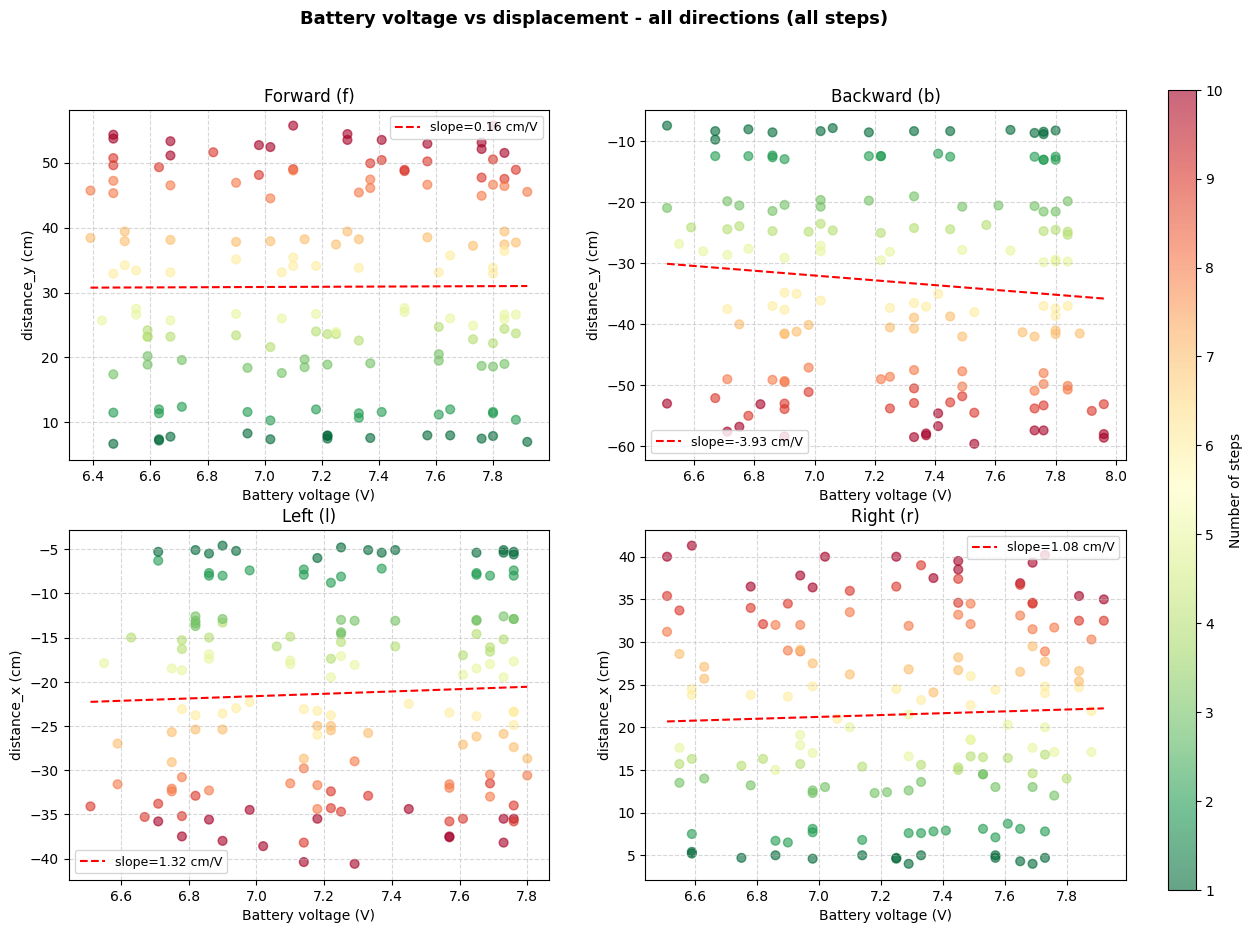

In [60]:
# Representation of the influence of the battery_volt parameter all steps and directions

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Battery voltage vs displacement - all directions (all steps)", fontsize=13, fontweight="bold")

dir_labels = {"f": "Forward", "b": "Backward", "l": "Left", "r": "Right"}
dir_axis = {"f": "distance_y", "b": "distance_y", "l": "distance_x", "r": "distance_x"}

cmap = plt.colormaps.get_cmap("RdYlGn").reversed()

for ax, direction in zip(axes.flatten(), ["f", "b", "l", "r"]):
    col_name = dir_axis[direction]
    sub = df[df["direction"] == direction]

    sc = ax.scatter(sub["battery_volt"], sub[col_name],
                    c=sub["steps"], cmap=cmap, vmin=1, vmax=10,
                    alpha=0.6, s=40)

    z = np.polyfit(sub["battery_volt"], sub[col_name], 1)
    bv = np.linspace(sub["battery_volt"].min(), sub["battery_volt"].max(), 100)
    ax.plot(bv, np.poly1d(z)(bv), "r--", lw=1.5, label="slope=" + str(round(z[0], 2)) + " cm/V")

    ax.set_xlabel("Battery voltage (V)")
    ax.set_ylabel(col_name + " (cm)")
    ax.set_title(dir_labels[direction] + " (" + direction + ")")
    ax.legend(fontsize=9)
    ax.grid(linestyle="--", alpha=0.5)

fig.subplots_adjust(right=0.88)
cbar_ax = fig.add_axes([0.91, 0.1, 0.02, 0.8])
cbar = fig.colorbar(sc, cax=cbar_ax)
cbar.set_label("Number of steps")
cbar.set_ticks(range(1, 11))

plt.show()

In [42]:
# Mean Error per direction on OOF predictions

print("Bias per direction - CV:\n")
for name in models:
    oof = oof_preds[name]
    print(f"[{name}]")
    for direction in ["f", "b", "l", "r"]:
        mask = X["direction"] == direction
        me_x = np.mean(oof[mask, 0] - y.loc[mask, "distance_x"].values)
        me_y = np.mean(oof[mask, 1] - y.loc[mask, "distance_y"].values)
        print(f" {direction}  ->  ME x={me_x:+.4f} cm   ME y={me_y:+.4f} cm")
    print()


Bias per direction - CV:

[Random Forest]
 f  ->  ME x=+0.0342 cm   ME y=+0.0209 cm
 b  ->  ME x=-0.0128 cm   ME y=+0.0377 cm
 l  ->  ME x=+0.0088 cm   ME y=-0.0871 cm
 r  ->  ME x=+0.0881 cm   ME y=+0.0964 cm

[XGBoost]
 f  ->  ME x=+0.1022 cm   ME y=-0.0083 cm
 b  ->  ME x=-0.0102 cm   ME y=+0.0159 cm
 l  ->  ME x=-0.0331 cm   ME y=-0.0252 cm
 r  ->  ME x=-0.0456 cm   ME y=-0.0419 cm

[MLP]
 f  ->  ME x=-0.0307 cm   ME y=+0.0127 cm
 b  ->  ME x=+0.0824 cm   ME y=-0.1402 cm
 l  ->  ME x=-0.0456 cm   ME y=-0.1850 cm
 r  ->  ME x=+0.0151 cm   ME y=-0.0833 cm



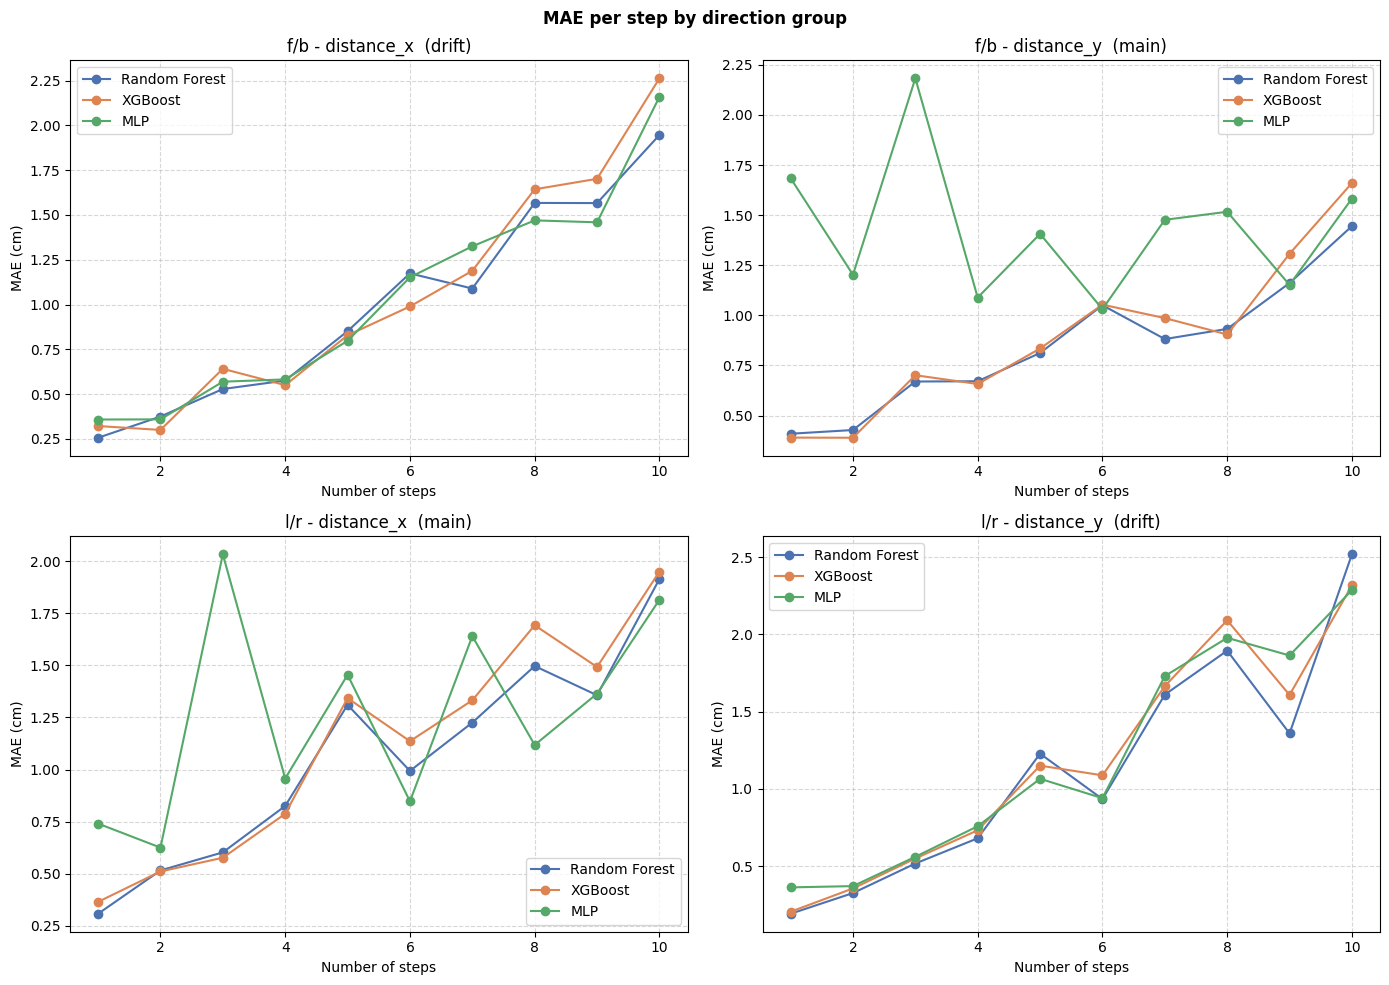

In [43]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("MAE per step by direction group", fontsize=12, fontweight="bold")

colors = {"Random Forest": "#4C72B0", "XGBoost": "#DD8452", "MLP": "#55A868"}

for name in models:
    oof = oof_preds[name]
    color = colors[name]
    mae = {k: [] for k in ["fb_x", "fb_y", "lr_x", "lr_y"]}

    for step in range(1, 11):
        mfb = (X["direction"].isin(["f", "b"]) & (X["steps"] == step)).values
        mlr = (X["direction"].isin(["l", "r"]) & (X["steps"] == step)).values
        mae["fb_x"].append(mean_absolute_error(y.loc[mfb, "distance_x"], oof[mfb, 0]))
        mae["fb_y"].append(mean_absolute_error(y.loc[mfb, "distance_y"], oof[mfb, 1]))
        mae["lr_x"].append(mean_absolute_error(y.loc[mlr, "distance_x"], oof[mlr, 0]))
        mae["lr_y"].append(mean_absolute_error(y.loc[mlr, "distance_y"], oof[mlr, 1]))

    axes[0,0].plot(range(1,11), mae["fb_x"], marker="o", color=color, label=name)
    axes[0,1].plot(range(1,11), mae["fb_y"], marker="o", color=color, label=name)
    axes[1,0].plot(range(1,11), mae["lr_x"], marker="o", color=color, label=name)
    axes[1,1].plot(range(1,11), mae["lr_y"], marker="o", color=color, label=name)

subplot_info = [
    (axes[0,0], "f/b - distance_x  (drift)"),
    (axes[0,1], "f/b - distance_y  (main)"),
    (axes[1,0], "l/r - distance_x  (main)"),
    (axes[1,1], "l/r - distance_y  (drift)"),
]
for ax, title in subplot_info:
    ax.set_title(title)
    ax.set_xlabel("Number of steps")
    ax.set_ylabel("MAE (cm)")
    ax.legend()
    ax.grid(linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


# Model Export

In [44]:
joblib.dump(models["Random Forest"], "model_rf.joblib")
joblib.dump(models["XGBoost"], "model_xgb.joblib")
joblib.dump(models["MLP"], "model_mlp.joblib")
print("Models saved.")

Models saved.


# Validation on real measurements
(using 80 data, 2 for every couple (direction-step))

In [45]:
df_real = pd.read_csv("movements_with_predictions.csv")

real_models = {
    "Random Forest": ("rf_x",  "rf_y"),
    "XGBoost": ("xgb_x", "xgb_y"),
    "MLP": ("mlp_x", "mlp_y"),
}

real_results = []
real_dir_results = []

for name, (col_x, col_y) in real_models.items():
    rx = df_real["distance_x"].values
    ry = df_real["distance_y"].values
    px = df_real[col_x].values
    py = df_real[col_y].values
    r2x = r2_score(rx, px)
    r2y = r2_score(ry, py)
    real_results.append({
        "Model": name,
        "MAE x (cm)": round(mean_absolute_error(rx, px), 4),
        "MAE y (cm)": round(mean_absolute_error(ry, py), 4),
        "RMSE x (cm)": round(np.sqrt(mean_squared_error(rx, px)), 4),
        "RMSE y (cm)": round(np.sqrt(mean_squared_error(ry, py)), 4),
        "R² x": round(r2x, 4),
        "R² y": round(r2y, 4),
        "Mean R²": round((r2x + r2y) / 2, 4),
    })

    for direction in ["f", "b", "l", "r"]:
        mask = df_real["direction"] == direction
        r2xd = r2_score(df_real.loc[mask, "distance_x"], df_real.loc[mask, col_x])
        r2yd = r2_score(df_real.loc[mask, "distance_y"], df_real.loc[mask, col_y])
        real_dir_results.append({
            "Model": name,
            "Direction": direction,
            "MAE x (cm)": round(mean_absolute_error(df_real.loc[mask,"distance_x"], df_real.loc[mask,col_x]), 4),
            "MAE y (cm)": round(mean_absolute_error(df_real.loc[mask,"distance_y"], df_real.loc[mask,col_y]), 4),
            "RMSE x (cm)": round(np.sqrt(mean_squared_error(df_real.loc[mask,"distance_x"], df_real.loc[mask,col_x])), 4),
            "RMSE y (cm)": round(np.sqrt(mean_squared_error(df_real.loc[mask,"distance_y"], df_real.loc[mask,col_y])), 4),
            "R² x": round(r2xd, 4),
            "R² y": round(r2yd, 4),
            "Mean R²": round((r2xd + r2yd) / 2, 4),
        })

df_real_results = (pd.DataFrame(real_results).sort_values("Mean R²", ascending=False).reset_index(drop=True))
df_real_dir = (pd.DataFrame(real_dir_results).sort_values(["Model", "Direction"]).reset_index(drop=True))

print(f"Real measurements: {len(df_real)}\n")
print("Global metrics :\n")
display(df_real_results)
print("\nSingle directions metrics:\n")
display(df_real_dir)


Real measurements: 80

Global metrics :



,Model,MAE x (cm),MAE y (cm),RMSE x (cm),RMSE y (cm),R² x,R² y,Mean R²
0,Random Forest,1.0024,0.9845,1.3212,1.3507,0.9938,0.9972,0.9955
1,MLP,1.0814,1.3800,1.4211,1.7625,0.9928,0.9953,0.9940
2,XGBoost,1.1101,1.0728,1.5769,1.5096,0.9912,0.9965,0.9938



Single directions metrics:



,Model,Direction,MAE x (cm),MAE y (cm),RMSE x (cm),RMSE y (cm),R² x,R² y,Mean R²
0,MLP,b,0.5320,1.4450,0.6937,1.7479,0.4916,0.9878,0.7397
1,MLP,f,0.9995,1.9175,1.2594,2.3319,0.5091,0.9787,0.7439
2,MLP,l,1.5915,0.9160,1.9012,1.1105,0.9653,0.8895,0.9274
3,MLP,r,1.2025,1.2415,1.5479,1.6429,0.9795,0.0196,0.4996
4,Random Forest,b,0.7290,0.9185,0.9255,1.1154,0.0951,0.9950,0.5450
5,Random Forest,f,1.0755,1.1315,1.4754,1.5788,0.3264,0.9902,0.6583
6,Random Forest,l,1.0855,0.6630,1.5250,0.9717,0.9777,0.9154,0.9465
7,Random Forest,r,1.1195,1.2250,1.2742,1.6177,0.9861,0.0495,0.5178
8,XGBoost,b,0.8475,1.0790,1.2072,1.3314,-0.5396,0.9929,0.2266
9,XGBoost,f,1.1350,1.3390,1.8510,1.9749,-0.0602,0.9847,0.4622


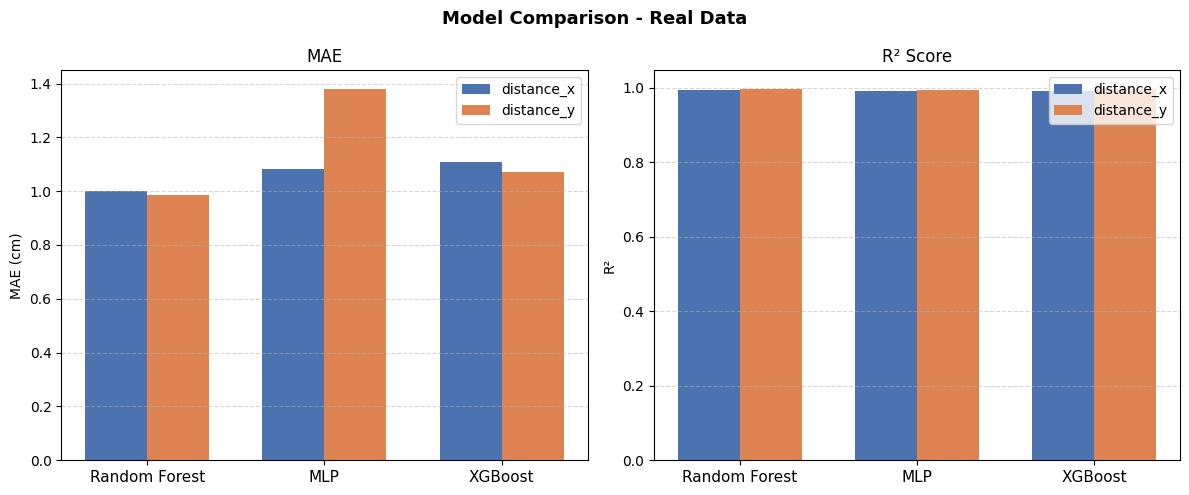

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Model Comparison - Real Data", fontsize=13, fontweight="bold")

names = df_real_results["Model"]
x = np.arange(len(names))
w = 0.35

axes[0].bar(x - w/2, df_real_results["MAE x (cm)"], w, label="distance_x", color="#4C72B0")
axes[0].bar(x + w/2, df_real_results["MAE y (cm)"], w, label="distance_y", color="#DD8452")
axes[0].set_xticks(x)
axes[0].set_xticklabels(names, fontsize=11)
axes[0].set_ylabel("MAE (cm)")
axes[0].set_title("MAE")
axes[0].legend()
axes[0].grid(axis="y", linestyle="--", alpha=0.5)

axes[1].bar(x - w/2, df_real_results["R² x"], w, label="distance_x", color="#4C72B0")
axes[1].bar(x + w/2, df_real_results["R² y"], w, label="distance_y", color="#DD8452")
axes[1].set_xticks(x)
axes[1].set_xticklabels(names, fontsize=11)
axes[1].set_ylabel("R²")
axes[1].set_title("R² Score")
axes[1].legend()
axes[1].grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


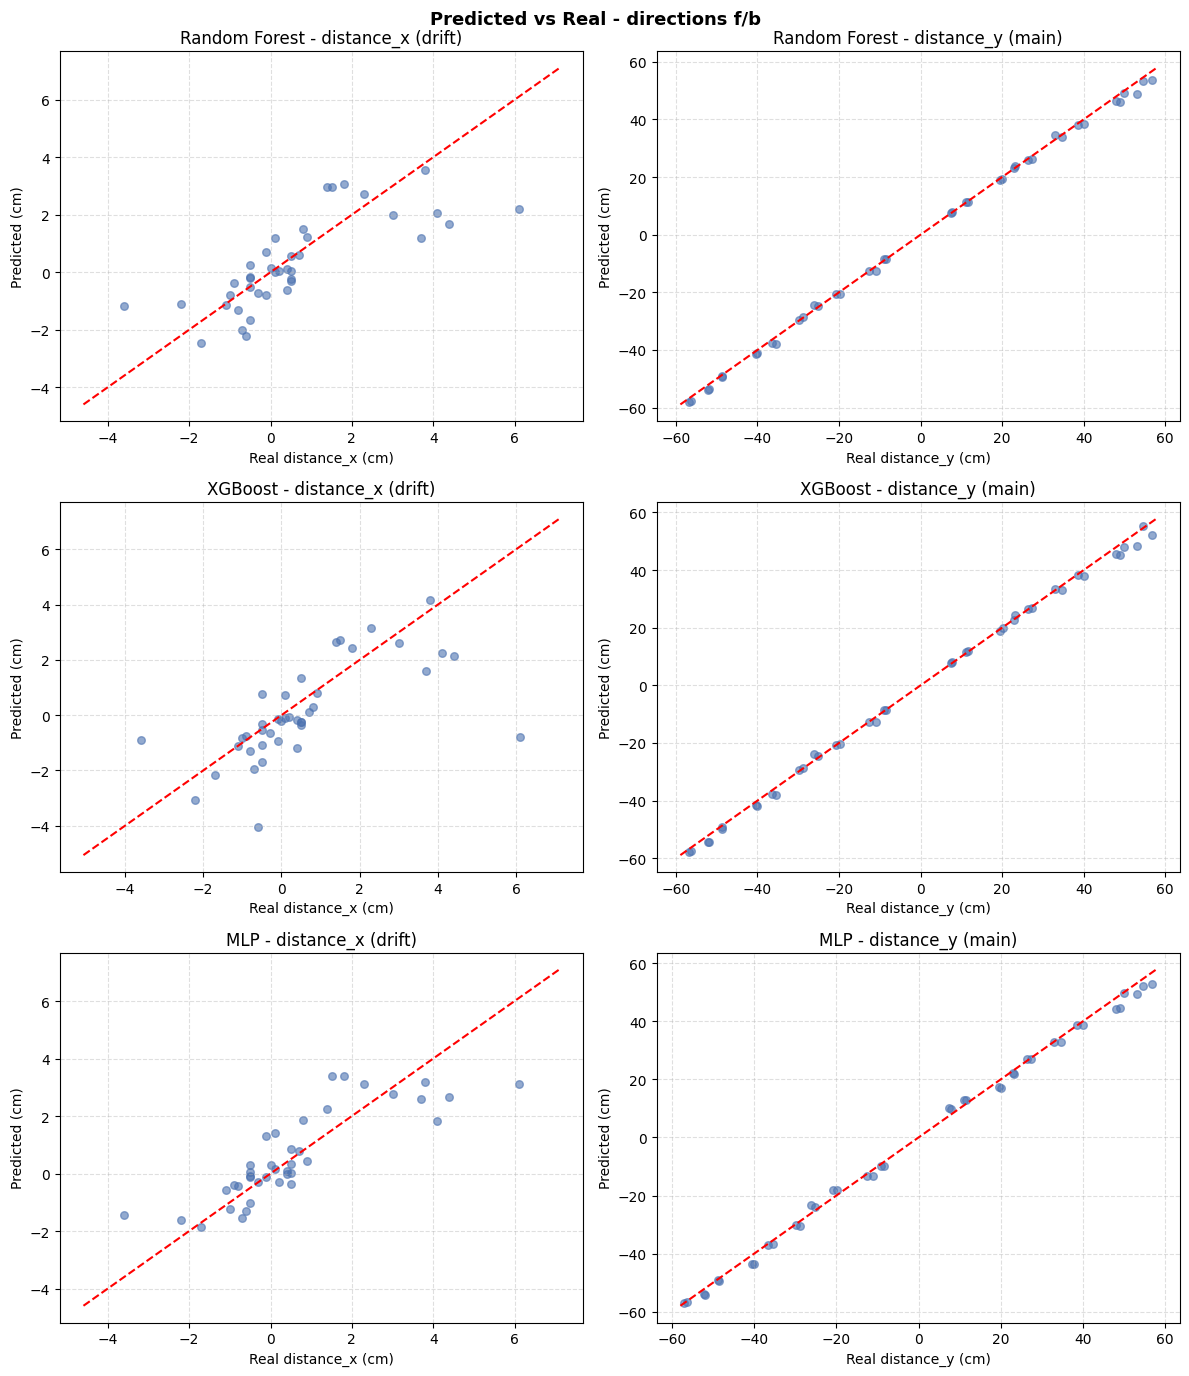

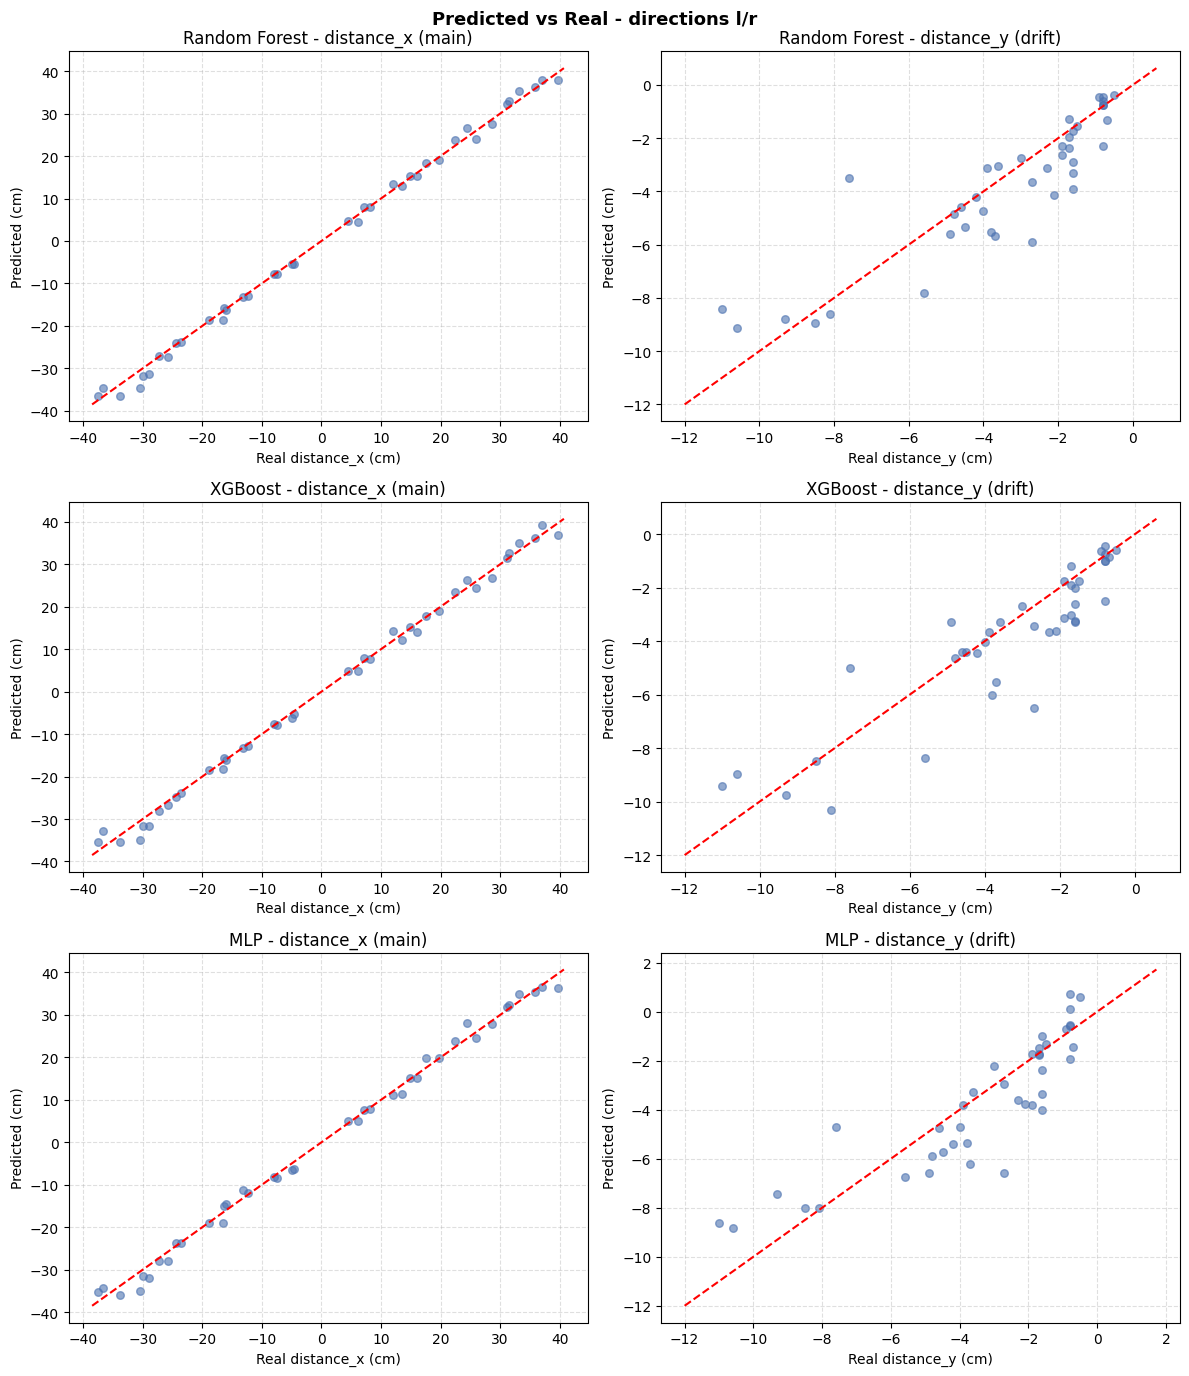

In [46]:
for group_dirs, group_label in [(["f", "b"], "f/b"), (["l", "r"], "l/r")]:
    fig, axes = plt.subplots(3, 2, figsize=(12, 14))
    fig.suptitle(
        "Predicted vs Real - directions " + group_label,
        fontsize=13, fontweight="bold"
    )
    mask = df_real["direction"].isin(group_dirs)

    for row_idx, (name, (col_x, col_y)) in enumerate(real_models.items()):
        for col_idx, (col_pred, col_real) in enumerate(
            [(col_x, "distance_x"), (col_y, "distance_y")]
        ):
            ax = axes[row_idx][col_idx]
            actual = df_real.loc[mask, col_real].values
            predicted = df_real.loc[mask, col_pred].values
            lim_min = min(actual.min(), predicted.min()) - 1
            lim_max = max(actual.max(), predicted.max()) + 1

            is_main = (
                (group_dirs == ["f","b"] and col_real == "distance_y") or
                (group_dirs == ["l","r"] and col_real == "distance_x")
            )
            axis_note = "main" if is_main else "drift"

            ax.scatter(actual, predicted, alpha=0.6, s=30, color="#4C72B0")
            ax.plot([lim_min, lim_max], [lim_min, lim_max], "r--", lw=1.5)
            ax.set_xlabel("Real " + col_real + " (cm)")
            ax.set_ylabel("Predicted (cm)")
            ax.set_title(name + " - " + col_real + " (" + axis_note + ")")
            ax.grid(linestyle="--", alpha=0.4)

    plt.tight_layout()
    plt.show()


In [47]:
print("Bias on real data:\n")
for name, (col_x, col_y) in real_models.items():
    print(f"[{name}]")
    for direction in ["f", "b", "l", "r"]:
        mask = df_real["direction"] == direction
        me_x = np.mean(df_real.loc[mask, col_x].values -
                       df_real.loc[mask, "distance_x"].values)
        me_y = np.mean(df_real.loc[mask, col_y].values -
                       df_real.loc[mask, "distance_y"].values)
        print(f" {direction}  ->  ME x={me_x:+.3f} cm   ME y={me_y:+.3f} cm")
    print()


Bias on real data:

[Random Forest]
 f  ->  ME x=-0.216 cm   ME y=-0.864 cm
 b  ->  ME x=-0.241 cm   ME y=-0.530 cm
 l  ->  ME x=-0.600 cm   ME y=-0.042 cm
 r  ->  ME x=+0.225 cm   ME y=-0.652 cm

[XGBoost]
 f  ->  ME x=-0.432 cm   ME y=-0.960 cm
 b  ->  ME x=-0.526 cm   ME y=-0.659 cm
 l  ->  ME x=-0.506 cm   ME y=-0.219 cm
 r  ->  ME x=+0.014 cm   ME y=-0.641 cm

[MLP]
 f  ->  ME x=+0.018 cm   ME y=-1.058 cm
 b  ->  ME x=+0.054 cm   ME y=-0.606 cm
 l  ->  ME x=-0.513 cm   ME y=+0.284 cm
 r  ->  ME x=+0.008 cm   ME y=-0.836 cm



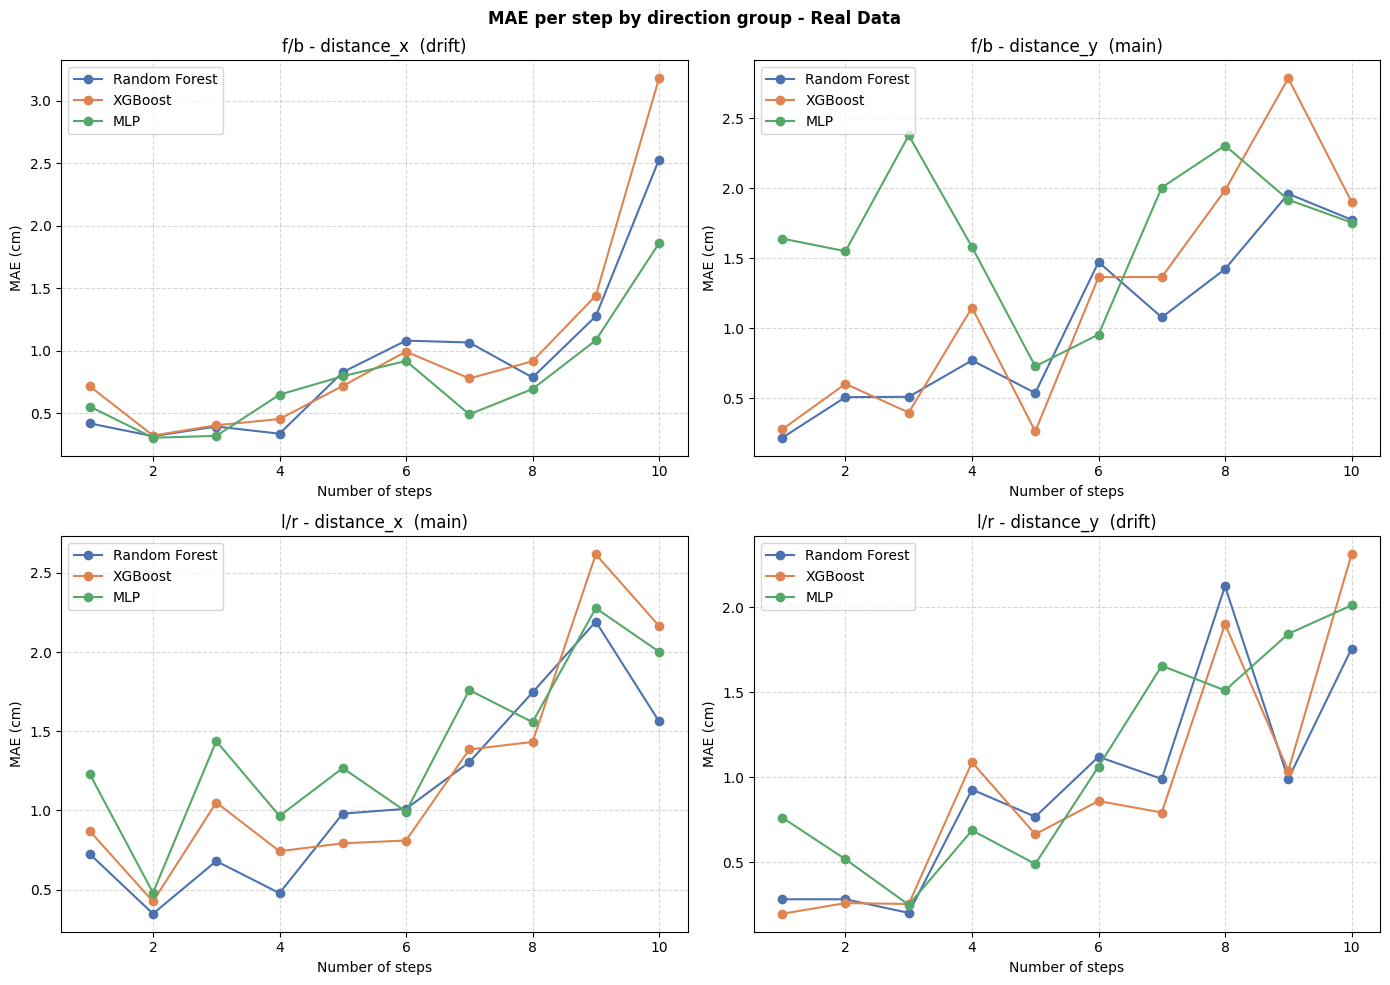

In [61]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("MAE per step by direction group - Real Data", fontsize=12, fontweight="bold")

colors = {"Random Forest": "#4C72B0", "XGBoost": "#DD8452", "MLP": "#55A868"}

for name, (col_x, col_y) in real_models.items():
    color = colors[name]
    mae = {k: [] for k in ["fb_x", "fb_y", "lr_x", "lr_y"]}

    for step in range(1, 11):
        mfb = df_real["direction"].isin(["f","b"]) & (df_real["steps"] == step)
        mlr = df_real["direction"].isin(["l","r"]) & (df_real["steps"] == step)
        mae["fb_x"].append(mean_absolute_error(df_real.loc[mfb,"distance_x"], df_real.loc[mfb, col_x]))
        mae["fb_y"].append(mean_absolute_error(df_real.loc[mfb,"distance_y"], df_real.loc[mfb, col_y]))
        mae["lr_x"].append(mean_absolute_error(df_real.loc[mlr,"distance_x"], df_real.loc[mlr, col_x]))
        mae["lr_y"].append(mean_absolute_error(df_real.loc[mlr,"distance_y"], df_real.loc[mlr, col_y]))

    axes[0,0].plot(range(1,11), mae["fb_x"], marker="o", color=color, label=name)
    axes[0,1].plot(range(1,11), mae["fb_y"], marker="o", color=color, label=name)
    axes[1,0].plot(range(1,11), mae["lr_x"], marker="o", color=color, label=name)
    axes[1,1].plot(range(1,11), mae["lr_y"], marker="o", color=color, label=name)

subplot_info = [
    (axes[0,0], "f/b - distance_x  (drift)"),
    (axes[0,1], "f/b - distance_y  (main)"),
    (axes[1,0], "l/r - distance_x  (main)"),
    (axes[1,1], "l/r - distance_y  (drift)"),
]
for ax, title in subplot_info:
    ax.set_title(title)
    ax.set_xlabel("Number of steps")
    ax.set_ylabel("MAE (cm)")
    ax.legend()
    ax.grid(linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


# Comparison between Cross-Validation and Real data

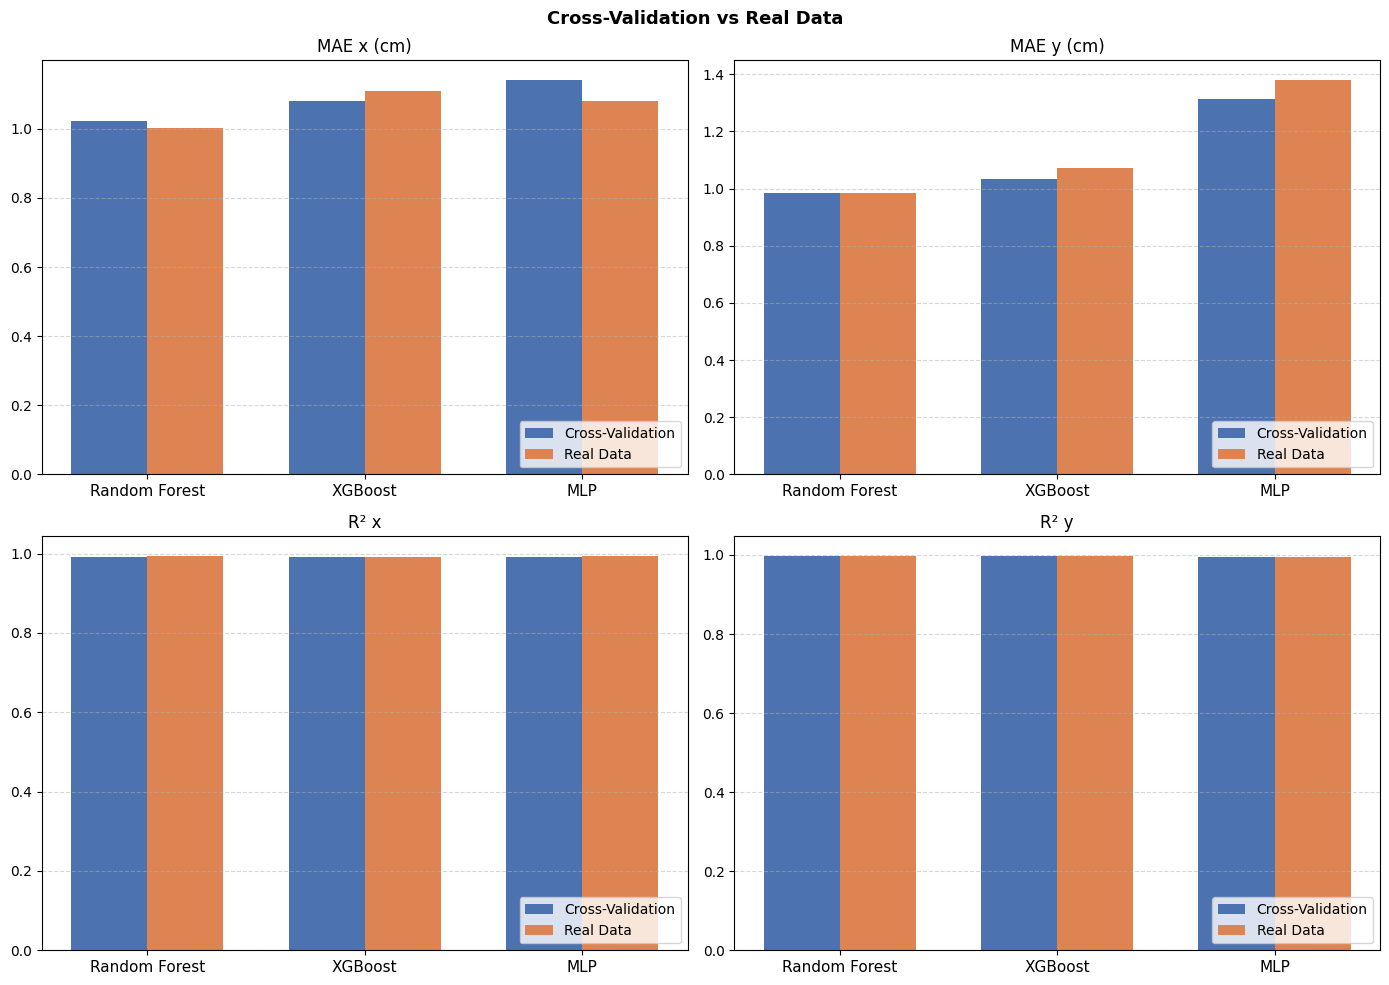

In [49]:
comparison = {}
for _, row in df_results.iterrows():
    comparison[row["Model"]] = {
        "cv_mae_x": row["MAE x (cm)"],
        "cv_mae_y": row["MAE y (cm)"],
        "cv_r2_x": row["R² x"],
        "cv_r2_y": row["R² y"],
    }
for _, row in df_real_results.iterrows():
    comparison[row["Model"]].update({
        "real_mae_x": row["MAE x (cm)"],
        "real_mae_y": row["MAE y (cm)"],
        "real_r2_x": row["R² x"],
        "real_r2_y": row["R² y"],
    })

model_names = list(comparison.keys())
x = np.arange(len(model_names))
w = 0.35

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Cross-Validation vs Real Data", fontsize=13, fontweight="bold")

panels = [
    (axes[0,0], "MAE x (cm)", "cv_mae_x", "real_mae_x"),
    (axes[0,1], "MAE y (cm)", "cv_mae_y", "real_mae_y"),
    (axes[1,0], "R² x", "cv_r2_x", "real_r2_x"),
    (axes[1,1], "R² y", "cv_r2_y", "real_r2_y"),
]
for ax, title, cv_key, real_key in panels:
    cv_vals = [comparison[n][cv_key] for n in model_names]
    real_vals = [comparison[n][real_key] for n in model_names]
    ax.bar(x - w/2, cv_vals, w, label="Cross-Validation", color="#4C72B0")
    ax.bar(x + w/2, real_vals, w, label="Real Data", color="#DD8452")
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, fontsize=11)
    ax.set_title(title)
    ax.legend(loc="lower right")
    ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


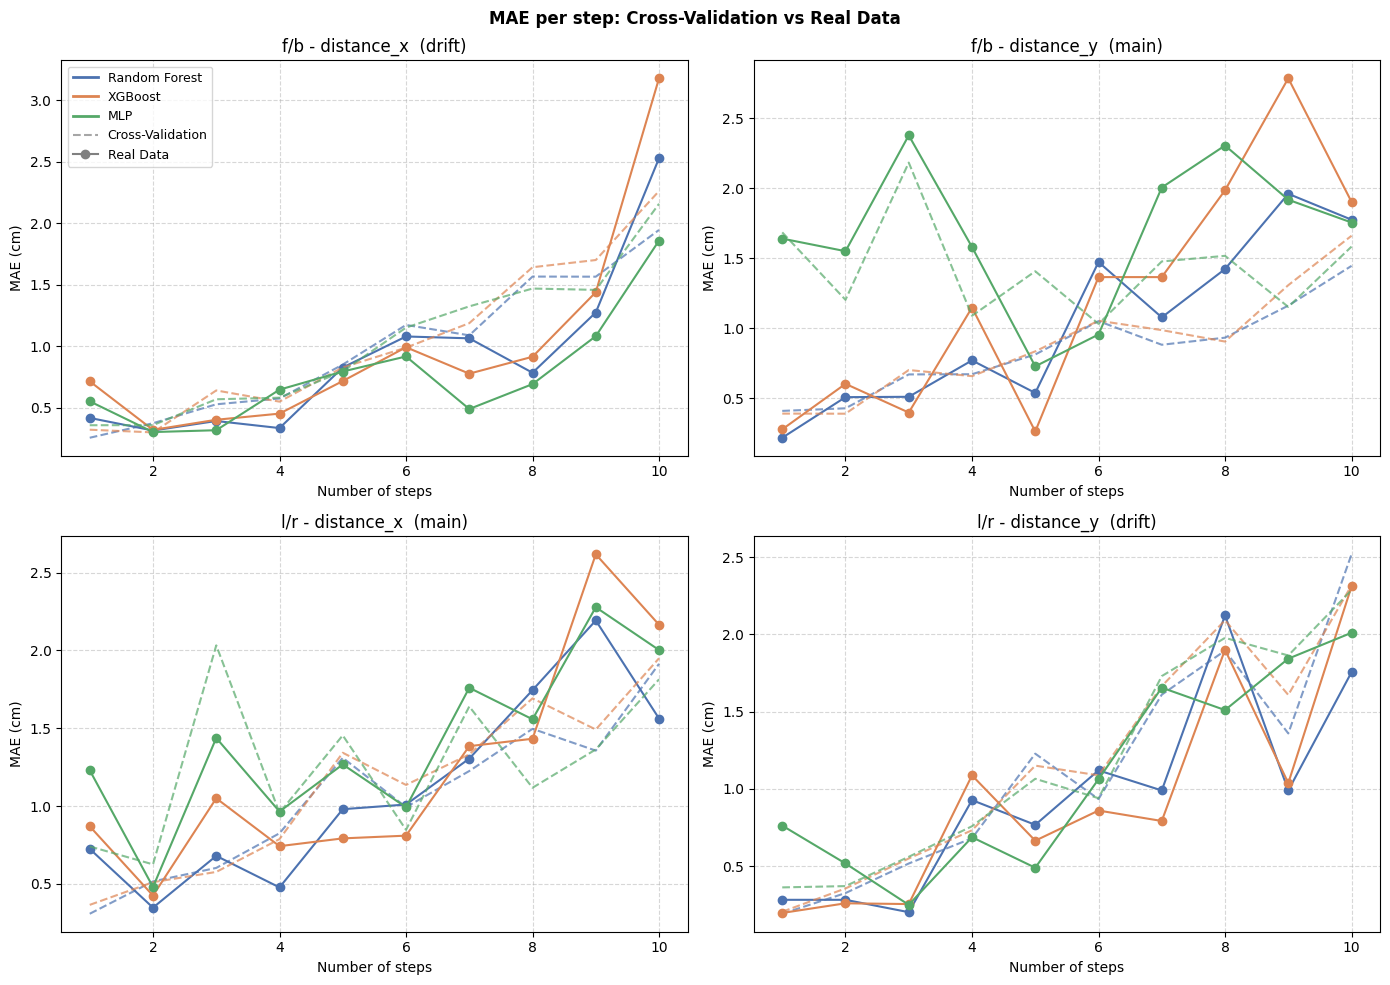

In [50]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("MAE per step: Cross-Validation vs Real Data", fontsize=12, fontweight="bold")

colors = {"Random Forest": "#4C72B0", "XGBoost": "#DD8452", "MLP": "#55A868"}

for name, (col_x, col_y) in real_models.items():
    oof = oof_preds[name]
    color = colors[name]
    cv_mae = {k: [] for k in ["fb_x","fb_y","lr_x","lr_y"]}
    real_mae = {k: [] for k in ["fb_x","fb_y","lr_x","lr_y"]}

    for step in range(1, 11):
        mfb_tr = (X["direction"].isin(["f","b"]) & (X["steps"]==step)).values
        mlr_tr = (X["direction"].isin(["l","r"]) & (X["steps"]==step)).values
        mfb_re = df_real["direction"].isin(["f","b"]) & (df_real["steps"]==step)
        mlr_re = df_real["direction"].isin(["l","r"]) & (df_real["steps"]==step)

        cv_mae["fb_x"].append(mean_absolute_error(y.loc[mfb_tr,"distance_x"], oof[mfb_tr,0]))
        cv_mae["fb_y"].append(mean_absolute_error(y.loc[mfb_tr,"distance_y"], oof[mfb_tr,1]))
        cv_mae["lr_x"].append(mean_absolute_error(y.loc[mlr_tr,"distance_x"], oof[mlr_tr,0]))
        cv_mae["lr_y"].append(mean_absolute_error(y.loc[mlr_tr,"distance_y"], oof[mlr_tr,1]))

        real_mae["fb_x"].append(mean_absolute_error(df_real.loc[mfb_re,"distance_x"], df_real.loc[mfb_re,col_x]))
        real_mae["fb_y"].append(mean_absolute_error(df_real.loc[mfb_re,"distance_y"], df_real.loc[mfb_re,col_y]))
        real_mae["lr_x"].append(mean_absolute_error(df_real.loc[mlr_re,"distance_x"], df_real.loc[mlr_re,col_x]))
        real_mae["lr_y"].append(mean_absolute_error(df_real.loc[mlr_re,"distance_y"], df_real.loc[mlr_re,col_y]))

    for ax, key in zip(axes.flatten(), ["fb_x","fb_y","lr_x","lr_y"]):
        ax.plot(range(1,11), cv_mae[key], linestyle="--", color=color, alpha=0.7)
        ax.plot(range(1,11), real_mae[key], linestyle="-", color=color, marker="o")

subplot_info = [
    "f/b - distance_x  (drift)",
    "f/b - distance_y  (main)",
    "l/r - distance_x  (main)",
    "l/r - distance_y  (drift)",
]
for ax, title in zip(axes.flatten(), subplot_info):
    ax.set_title(title)
    ax.set_xlabel("Number of steps")
    ax.set_ylabel("MAE (cm)")
    ax.grid(linestyle="--", alpha=0.5)

handles_models = [Line2D([0],[0], color=c, lw=2, label=n) for n, c in colors.items()]
handles_styles = [
    Line2D([0],[0], linestyle="--", color="gray", alpha=0.7, label="Cross-Validation"),
    Line2D([0],[0], linestyle="-",  color="gray", marker="o", label="Real Data"),
]
axes[0,0].legend(handles=handles_models + handles_styles, fontsize=9)

plt.tight_layout()
plt.show()
